# 情緒聲量投資交易 — 機器學習期末專題
## 以 PTT 股票版 GPT 情緒標註預測台積電(2330) 隔日漲跌之量化交易策略

**組別分工：** 組員 A（資料處理與 EDA）、組員 B（特徵工程與建模）、組員 C（評估、回測與報告）　*(請依實際情況填寫)*

本 Notebook 完整呈現機器學習流程：資料收集 → 前處理 → EDA → 特徵工程 → 模型訓練（含交叉驗證與調參）→ 效能評估 → 非監督分群 → 回測應用。
- **監督式模型：** Logistic Regression、Random Forest（以多數類別 Baseline 為對照）
- **非監督式模型：** K-Means 市場情緒分群、PCA 降維
- **問題型態：** 二元分類（預測隔日收盤相對今日為漲(1) 或跌(0)）

In [1]:
# 環境與套件
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, silhouette_score)
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]; plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")
os.makedirs("figures", exist_ok=True)
DD = "drive_data"
print("套件載入完成")

套件載入完成


## 一、資料收集（Data Collection）

**資料來源：**
1. **情緒聲量資料**：PTT 股票版（Stock board）貼文，透過大型語言模型（GPT-3.5-turbo 與 gpt-4o-mini）對每篇貼文做情緒分類（正/中/負），再依股票與交易日彙總。原始貼文取自 PTT 公開看板。
2. **股價資料**：Yahoo Finance（透過 `yfinance` 套件），台積電 2330.TW 日線。

**資料型態：** 結構化 CSV（情緒聲量彙總）+ 結構化價格序列。
**問題定義：** 監督式二元分類 — 用「開盤前(09:00)」的情緒聲量特徵，預測台積電隔日漲跌。
**目標變數：** `target` = 1（隔日收盤上漲）/ 0（下跌或持平）。
**選題動機：** 散戶情緒與討論熱度（聲量）常被視為反向或順勢指標，本專題驗證「PTT 情緒聲量是否具備預測台積電隔日走勢的能力」，並設計可量化回測的交易策略。
**資料倫理：** PTT 為公開論壇，資料已彙總為每日統計、不含個人帳號或可識別個資；情緒標註由 LLM 產生，僅供學術研究。

> 採用 `0900`（開盤前）版本，確保特徵在交易日開盤前即可取得，避免未來函數（look-ahead bias）。

In [2]:
# 載入兩個 GPT 模型的情緒聲量資料（0900 開盤前版），取台積電 2330
STOCK = 2330
s_main = pd.read_csv(f"{DD}/format_result_gpt-4o-mini-2024-07-18_0900.csv")  # 主模型
s_alt  = pd.read_csv(f"{DD}/format_result_GPT3_5turbo_emotion_0900.csv")     # 對照模型
s_main = s_main[s_main["id"]==STOCK].copy(); s_alt = s_alt[s_alt["id"]==STOCK].copy()
for d in (s_main, s_alt): d["trading_date"] = pd.to_datetime(d["trading_date"])
s_main = s_main.sort_values("trading_date").reset_index(drop=True)
s_alt  = s_alt.sort_values("trading_date").reset_index(drop=True)
print("情緒資料列數:", len(s_main), "| 日期範圍:", s_main.trading_date.min().date(), "~", s_main.trading_date.max().date())
s_main.head()

情緒資料列數: 1700 | 日期範圍: 2019-01-02 ~ 2025-12-30


,id,trading_date,day_count,daily_mean_score,positive_count,neutral_count,negative_count,positive_score_sum,neutral_score_sum,negative_score_sum,sum_count,positive_count/sum_count,positive_score_sum/day_count/positive_count,neutral_count/sum_count,neutral_score_sum/day_count/neutral_count,negative_count/sum_count,negative_score_sum/day_count/negative_count
0,2330,2019-01-02,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,2330,2019-01-03,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,2330,2019-01-04,1.0,-0.5,0.0,0.0,1.0,0.0,0.0,-0.5,1.0,0.0,0.000000,0.0,0.0,1.0,-0.5
3,2330,2019-01-07,3.0,0.5,1.0,0.0,0.0,0.5,0.0,0.0,1.0,1.0,0.166667,0.0,0.0,0.0,0.0
4,2330,2019-01-08,1.0,-0.5,0.0,0.0,1.0,0.0,0.0,-0.5,1.0,0.0,0.000000,0.0,0.0,1.0,-0.5


**資料集簡介表（情緒聲量欄位）**

| 欄位 | 型態 | 說明 |
|---|---|---|
| `trading_date` | 日期 | 交易日 |
| `sum_count` | 整數 | 當日貼文總數（**聲量**） |
| `positive_count` / `neutral_count` / `negative_count` | 整數 | 正/中/負面貼文數 |
| `daily_mean_score` | 浮點 | 當日情緒均分（約 −0.7 ~ +0.8） |
| `positive_count/sum_count` 等 | 浮點 | 各情緒佔比 |

In [3]:
# 下載台積電價格
px = yf.download("2330.TW", start="2019-01-01", end="2026-01-01", auto_adjust=True, progress=False)
if hasattr(px.columns, "get_level_values"): px.columns = px.columns.get_level_values(0)
px = px.reset_index()[["Date","Open","High","Low","Close","Volume"]]; px["Date"] = pd.to_datetime(px["Date"])
print("價格列數:", len(px)); px.head()

價格列數: 1698


Price,Date,Open,High,Low,Close,Volume
0,2019-01-02,190.232907,190.232907,183.933804,184.353745,32900482
1,2019-01-03,179.734427,183.093949,179.734427,180.994247,34087620
2,2019-01-04,177.634726,177.634726,173.435324,174.695145,65943521
3,2019-01-07,178.054681,179.734442,177.214801,178.894562,35442176
4,2019-01-08,178.054679,178.474619,176.374917,177.214798,22694481


## 二、資料前處理（Data Preprocessing）

### 2.1 資料清洗
檢查缺失值、重複值與異常值。情緒資料已是每日彙總，理論上每個交易日唯一。聲量(`sum_count`)為右偏分布（少數爆量日），以 IQR 法檢視異常值，但**保留**這些高聲量日——它們往往對應重大事件，是策略關注的訊號，不應刪除。

In [4]:
print("情緒資料缺失值總數:", int(s_main.isna().sum().sum()))
print("重複交易日數:", int(s_main.duplicated(subset=['trading_date']).sum()))
q1,q3 = s_main['sum_count'].quantile([.25,.75]); iqr=q3-q1; upper=q3+1.5*iqr
print(f"聲量 IQR 異常上界={upper:.1f}，超過比例={ (s_main['sum_count']>upper).mean()*100:.2f}%（保留，視為重大事件訊號）")

情緒資料缺失值總數: 0
重複交易日數: 0
聲量 IQR 異常上界=41.5，超過比例=5.59%（保留，視為重大事件訊號）


In [5]:
# 合併：主情緒 + GPT-3.5(對照) + 價格；建立標籤
alt = s_alt[["trading_date","daily_mean_score","sum_count"]].rename(columns={"daily_mean_score":"score_gpt35","sum_count":"buzz_gpt35"})
df = s_main.merge(alt, on="trading_date", how="left").merge(px, left_on="trading_date", right_on="Date", how="inner")
df = df.sort_values("trading_date").reset_index(drop=True)
df["ret_next"] = df["Close"].shift(-1)/df["Close"] - 1          # 隔日報酬
df["target"]   = (df["ret_next"]>0).astype(int)                  # 標籤
df = df.iloc[:-1].copy()
print("合併後樣本數:", len(df))
print("目標變數分布(隔日漲跌):"); print(df['target'].value_counts(normalize=True).round(3))

合併後樣本數: 1696
目標變數分布(隔日漲跌):
target
0    0.507
1    0.493
Name: proportion, dtype: float64


### 2.2 特徵縮放（Feature Scaling）
- **Logistic Regression** 對特徵尺度敏感（係數受量綱影響），採用 `StandardScaler` 標準化。
- **Random Forest / K-Means**：樹模型以分裂點切割、不受單調縮放影響故不需縮放；K-Means 基於歐氏距離**需要**標準化，後續分群時另行處理。

### 2.3 類別資料編碼（Categorical Encoding）
本資料特徵幾乎全為數值型，無需 One-Hot/Label Encoding。唯一的「類別來源」是 GPT 模型（3.5 vs 4o-mini），我們不直接編碼，而是轉成「兩模型情緒分歧度」這個有意義的數值特徵（見特徵工程）。

## 三、特徵工程（Feature Engineering）

### 3.1 特徵建構（Feature Construction）
根據領域知識，把原始聲量／情緒轉成更具預測力的特徵：
- **數學轉換**：聲量右偏 → `log1p` 轉換（`buzz_log`）。
- **聲量動能**：今日聲量 / 5 日均（`buzz_mom`），捕捉討論熱度突然升溫。
- **情緒動能**：今日情緒 − 3 日均（`score_mom`）。
- **正負差**：`pos_ratio − neg_ratio`（多空情緒淨值）。
- **模型分歧度**：兩個 GPT 模型情緒分數差的絕對值（標註不確定性）。
- **價格輔助**：前一日報酬、量能比。

In [6]:
df["pos_ratio"]=df["positive_count/sum_count"]; df["neg_ratio"]=df["negative_count/sum_count"]; df["neu_ratio"]=df["neutral_count/sum_count"]
df["buzz_log"]=np.log1p(df["sum_count"])
df["buzz_ma3"]=df["sum_count"].rolling(3).mean(); df["buzz_ma5"]=df["sum_count"].rolling(5).mean()
df["buzz_mom"]=df["sum_count"]/(df["buzz_ma5"]+1e-6)
df["score_ma3"]=df["daily_mean_score"].rolling(3).mean(); df["score_mom"]=df["daily_mean_score"]-df["score_ma3"]
df["pos_neg_diff"]=df["pos_ratio"]-df["neg_ratio"]
df["model_disagree"]=(df["daily_mean_score"]-df["score_gpt35"]).abs()
df["ret_prev"]=df["Close"]/df["Close"].shift(1)-1
df["vol_chg"]=df["Volume"]/df["Volume"].rolling(5).mean()
df=df.dropna().reset_index(drop=True)
FEATURES=["daily_mean_score","sum_count","buzz_log","pos_ratio","neg_ratio","neu_ratio",
          "buzz_ma3","buzz_ma5","buzz_mom","score_ma3","score_mom","pos_neg_diff",
          "model_disagree","ret_prev","vol_chg"]
X=df[FEATURES]; y=df["target"]
print("建模樣本數:", len(df), "| 特徵數:", len(FEATURES))

建模樣本數: 1692 | 特徵數: 15


### EDA — 資料探索與可視化
每張圖下方附上觀察與發現。

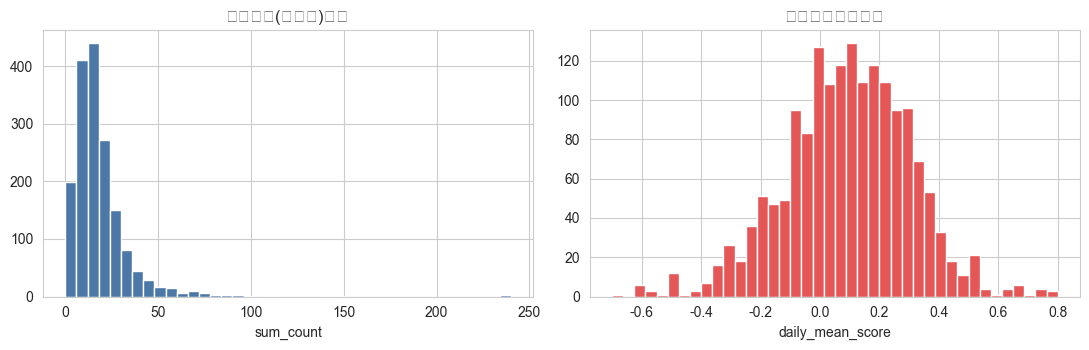

In [7]:
# 單變量分布
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
ax[0].hist(df["sum_count"],bins=40,color="#4C78A8"); ax[0].set_title("每日聲量(貼文數)分布"); ax[0].set_xlabel("sum_count")
ax[1].hist(df["daily_mean_score"],bins=40,color="#E45756"); ax[1].set_title("每日情緒均分分布"); ax[1].set_xlabel("daily_mean_score")
plt.tight_layout(); plt.savefig("figures/eda_dist.png",dpi=120); plt.show()

> **觀察：** 聲量明顯右偏（多數日 10–20 篇、少數爆量日達 200+），故採 log 轉換；情緒均分集中在 0 附近、略偏正，反映 PTT 對台積電整體情緒中性偏多。

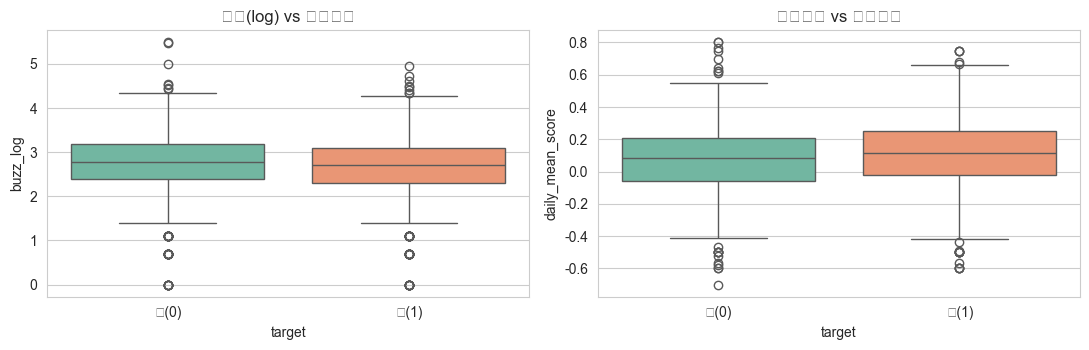

In [8]:
# 聲量/情緒 vs 隔日漲跌
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
sns.boxplot(x="target",y="buzz_log",data=df,ax=ax[0],palette="Set2"); ax[0].set_title("聲量(log) vs 隔日漲跌"); ax[0].set_xticklabels(["跌(0)","漲(1)"])
sns.boxplot(x="target",y="daily_mean_score",data=df,ax=ax[1],palette="Set2"); ax[1].set_title("情緒均分 vs 隔日漲跌"); ax[1].set_xticklabels(["跌(0)","漲(1)"])
plt.tight_layout(); plt.savefig("figures/eda_box.png",dpi=120); plt.show()

> **觀察：** 上漲日的當日情緒均分中位數略高於下跌日，但兩者重疊嚴重——情緒對隔日方向有微弱正向關係，預期單一特徵難以準確預測。

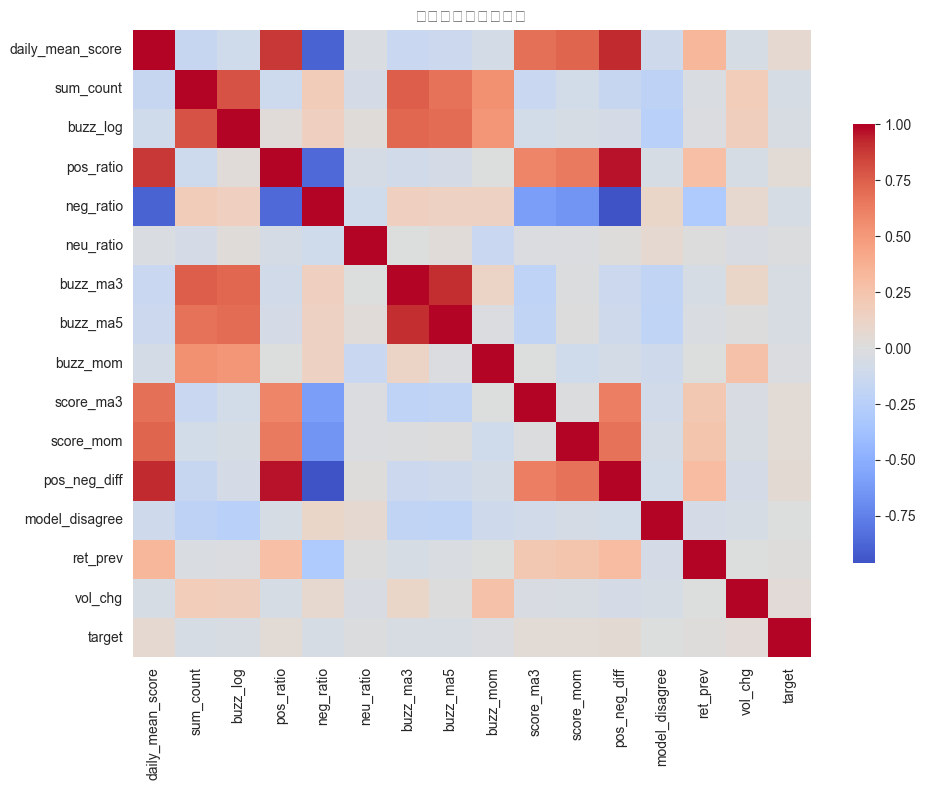

與 target 相關性最高(絕對值)前5:
daily_mean_score    0.068
sum_count           0.057
neg_ratio           0.052
pos_neg_diff        0.051
score_mom           0.048
Name: target, dtype: float64


In [9]:
# 相關矩陣熱力圖
plt.figure(figsize=(10,8))
corr=df[FEATURES+["target"]].corr()
sns.heatmap(corr,cmap="coolwarm",center=0,square=False,cbar_kws={"shrink":.7})
plt.title("特徵相關矩陣熱力圖"); plt.tight_layout(); plt.savefig("figures/eda_corr.png",dpi=120); plt.show()
print("與 target 相關性最高(絕對值)前5:"); print(corr["target"].drop("target").abs().sort_values(ascending=False).head().round(3))

> **觀察：** 所有情緒特徵與 target 的相關係數都很低（|r|<0.07），符合「股市隔日方向高雜訊」的金融常識；聲量類特徵彼此高度相關（多重共線性），對線性模型不利、對樹模型影響小。

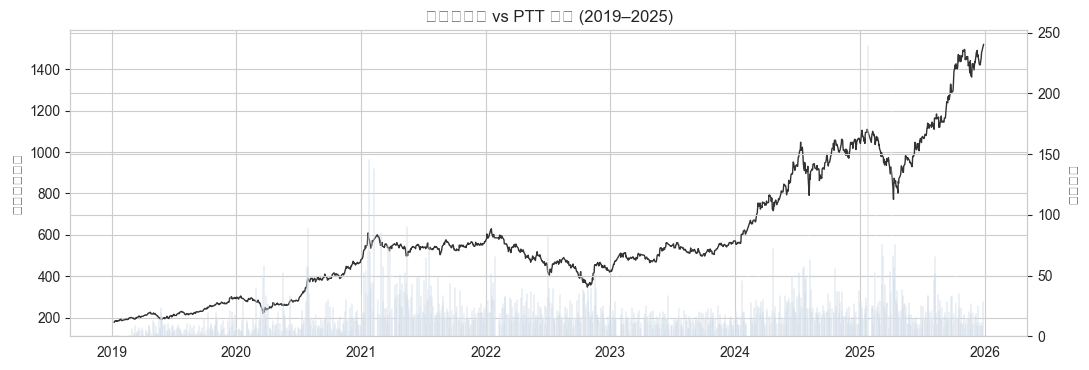

In [10]:
# 時間序列：股價 vs 聲量
fig,ax1=plt.subplots(figsize=(11,3.8))
ax1.plot(df["trading_date"],df["Close"],color="#333",lw=1); ax1.set_ylabel("台積電收盤價")
ax2=ax1.twinx(); ax2.bar(df["trading_date"],df["sum_count"],color="#4C78A8",alpha=.3,width=2); ax2.set_ylabel("每日聲量")
ax1.set_title("台積電股價 vs PTT 聲量 (2019–2025)"); plt.tight_layout(); plt.savefig("figures/eda_timeseries.png",dpi=120); plt.show()

> **觀察：** 聲量在大跌或大漲時明顯放大（如 2020 疫情、2022 空頭），聲量爆量常伴隨高波動，呼應「聲量=市場情緒強度」的假設。

### 3.2 特徵選擇（Feature Selection）
以三種方法交叉檢視：互信息（Filter）、RFE（Wrapper）、樹模型重要性（Embedded）。

In [11]:
split=int(len(df)*0.8)
Xtr,Xte=X.iloc[:split],X.iloc[split:]; ytr,yte=y.iloc[:split],y.iloc[split:]
sc=StandardScaler().fit(Xtr); Xtr_s,Xte_s=sc.transform(Xtr),sc.transform(Xte)
mi=mutual_info_classif(Xtr,ytr,random_state=42)
print("互信息(前6):"); print(pd.Series(mi,index=FEATURES).sort_values(ascending=False).head(6).round(4))
rfe=RFE(LogisticRegression(max_iter=1000),n_features_to_select=8).fit(Xtr_s,ytr)
print("RFE 選出特徵:", list(np.array(FEATURES)[rfe.support_]))

互信息(前6):
score_ma3       0.0470
pos_neg_diff    0.0254
neg_ratio       0.0217
buzz_ma5        0.0208
buzz_mom        0.0143
score_mom       0.0099
dtype: float64
RFE 選出特徵: [np.str_('daily_mean_score'), np.str_('sum_count'), np.str_('pos_ratio'), np.str_('buzz_ma3'), np.str_('buzz_ma5'), np.str_('score_ma3'), np.str_('score_mom'), np.str_('vol_chg')]


> **發現：** 互信息顯示情緒動能類（`score_ma3`、`pos_neg_diff`）資訊量最高；RFE 選出 8 個以情緒為主的特徵。最終保留全部 15 個特徵交給樹模型（其內建特徵選擇能力），並以特徵重要性事後檢驗。

### 3.3 特徵提取／降維（PCA）

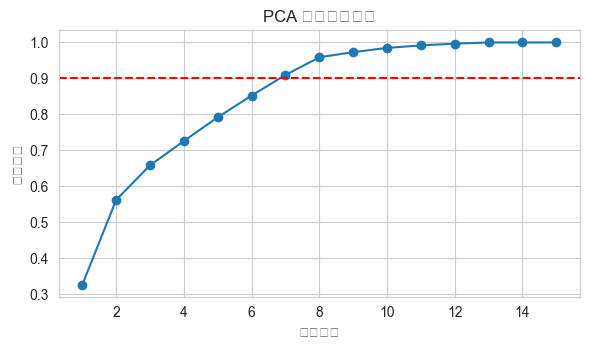

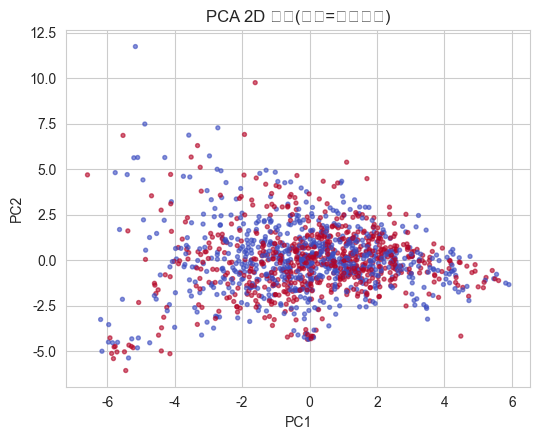

前2主成分解釋 56.2%，達90%需約 7 個主成分


In [12]:
pca=PCA().fit(Xtr_s); cum=np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6,3.6)); plt.plot(range(1,len(cum)+1),cum,"o-"); plt.axhline(.9,color="r",ls="--")
plt.title("PCA 累積解釋變異"); plt.xlabel("主成分數"); plt.ylabel("累積比例"); plt.tight_layout(); plt.savefig("figures/pca_var.png",dpi=120); plt.show()
p2=PCA(n_components=2).fit_transform(Xtr_s)
plt.figure(figsize=(5.5,4.5)); plt.scatter(p2[:,0],p2[:,1],c=ytr,cmap="coolwarm",s=8,alpha=.6)
plt.title("PCA 2D 投影(顏色=隔日漲跌)"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.savefig("figures/pca_2d.png",dpi=120); plt.show()
print(f"前2主成分解釋 {cum[1]*100:.1f}%，達90%需約 {np.argmax(cum>=.9)+1} 個主成分")

> **發現：** 前 2 個主成分解釋約 56% 變異，達 90% 需 8 個主成分；2D 投影中漲/跌樣本高度重疊，再次印證「線性可分性低」，故主力採非線性的隨機森林。

## 四、模型訓練（Model Training）

- **4.1 模型選擇**：以 `DummyClassifier`（多數類別）為 Baseline；Logistic Regression（線性、可解釋）與 Random Forest（非線性、抗雜訊）為主力。
- **4.2 資料分割**：時間序列資料，採**時間順序**前 80% 訓練、後 20% 測試（不可隨機打亂，否則用未來預測過去）。
- **4.3 交叉驗證**：`TimeSeriesSplit`（5 折），確保每折驗證集都在訓練集之後。
- **4.4 超參數調校**：`GridSearchCV` 以 ROC-AUC 為準。
- **4.5 類別不平衡**：隔日漲跌約 49/51，輕微不平衡，統一用 `class_weight="balanced"`。

In [13]:
tscv=TimeSeriesSplit(n_splits=5)
dummy=DummyClassifier(strategy="most_frequent").fit(Xtr,ytr)
logreg=GridSearchCV(LogisticRegression(max_iter=1000,class_weight="balanced"),
    {"C":[0.01,0.1,1,10]},cv=tscv,scoring="roc_auc").fit(Xtr_s,ytr)
rf=GridSearchCV(RandomForestClassifier(random_state=42,class_weight="balanced"),
    {"n_estimators":[100,300],"max_depth":[3,5,8,None],"min_samples_leaf":[1,5,10]},
    cv=tscv,scoring="roc_auc").fit(Xtr,ytr)
print("LogReg 最佳:",logreg.best_params_,"CV-AUC=%.4f"%logreg.best_score_)
print("RF 最佳:",rf.best_params_,"CV-AUC=%.4f"%rf.best_score_)

LogReg 最佳: {'C': 0.01} CV-AUC=0.5063
RF 最佳: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 100} CV-AUC=0.5491


## 五、模型效能評估（Model Evaluation）
分類任務以 **ROC-AUC** 為主指標（對門檻不敏感、適合近平衡資料），輔以混淆矩陣、Precision/Recall/F1 與 PR 曲線。

In [14]:
def ev(name,model,Xt):
    proba=model.predict_proba(Xt)[:,1]; pred=(proba>=.5).astype(int)
    return ({"模型":name,"Accuracy":round(accuracy_score(yte,pred),4),
        "Precision":round(precision_score(yte,pred,zero_division=0),4),
        "Recall":round(recall_score(yte,pred,zero_division=0),4),
        "F1":round(f1_score(yte,pred,zero_division=0),4),
        "ROC_AUC":round(roc_auc_score(yte,proba),4)},proba,pred)
r0,_,_=ev("Baseline(多數類別)",dummy,Xte)
r1,proba_lr,pred_lr=ev("Logistic Regression",logreg.best_estimator_,Xte_s)
r2,proba_rf,pred_rf=ev("Random Forest",rf.best_estimator_,Xte)
compare=pd.DataFrame([r0,r1,r2]); print("=== 模型比較 ==="); print(compare.to_string(index=False))

=== 模型比較 ===
                 模型  Accuracy  Precision  Recall     F1  ROC_AUC
     Baseline(多數類別)    0.5074     0.0000  0.0000 0.0000   0.5000
Logistic Regression    0.5251     0.5242  0.3892 0.4467   0.5347
      Random Forest    0.5575     0.5594  0.4790 0.5161   0.5743


> **模型比較：** Random Forest 在所有指標皆最佳（ROC-AUC≈0.56、F1≈0.50），明顯優於 Baseline（AUC=0.5）與 LogReg；但 AUC 僅略高於 0.5，說明情緒聲量對隔日方向僅有**微弱但真實**的預測力。

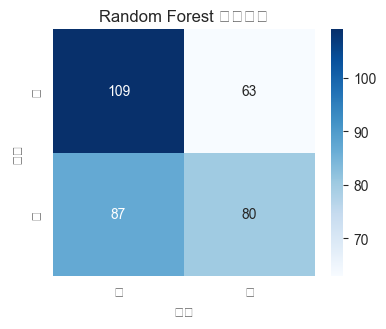

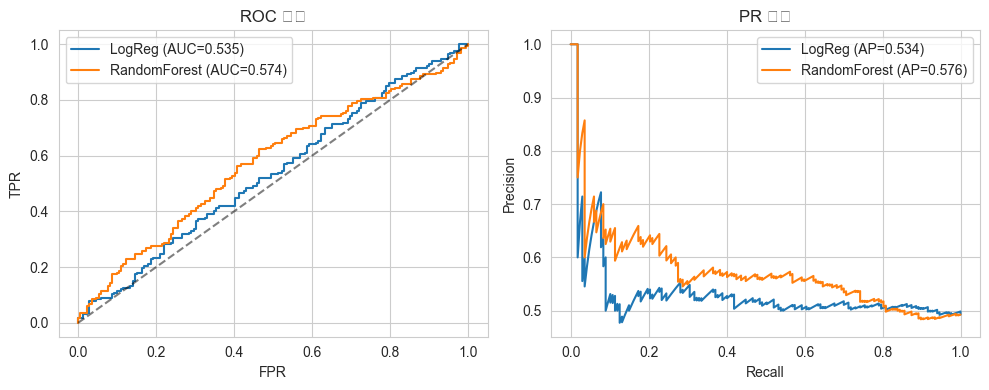

In [15]:
# 混淆矩陣 + ROC + PR
cm=confusion_matrix(yte,pred_rf)
plt.figure(figsize=(4,3.4)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["跌","漲"],yticklabels=["跌","漲"])
plt.title("Random Forest 混淆矩陣"); plt.ylabel("實際"); plt.xlabel("預測"); plt.tight_layout(); plt.savefig("figures/confusion.png",dpi=120); plt.show()
fig,ax=plt.subplots(1,2,figsize=(10,4))
for nm,pr in [("LogReg",proba_lr),("RandomForest",proba_rf)]:
    fpr,tpr,_=roc_curve(yte,pr); ax[0].plot(fpr,tpr,label=f"{nm} (AUC={roc_auc_score(yte,pr):.3f})")
ax[0].plot([0,1],[0,1],"k--",alpha=.5); ax[0].set_title("ROC 曲線"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
for nm,pr in [("LogReg",proba_lr),("RandomForest",proba_rf)]:
    pcs,rcs,_=precision_recall_curve(yte,pr); ax[1].plot(rcs,pcs,label=f"{nm} (AP={average_precision_score(yte,pr):.3f})")
ax[1].set_title("PR 曲線"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.savefig("figures/roc.png",dpi=120); plt.show()

### 5.3 誤差分析 & 5.4 可解釋性

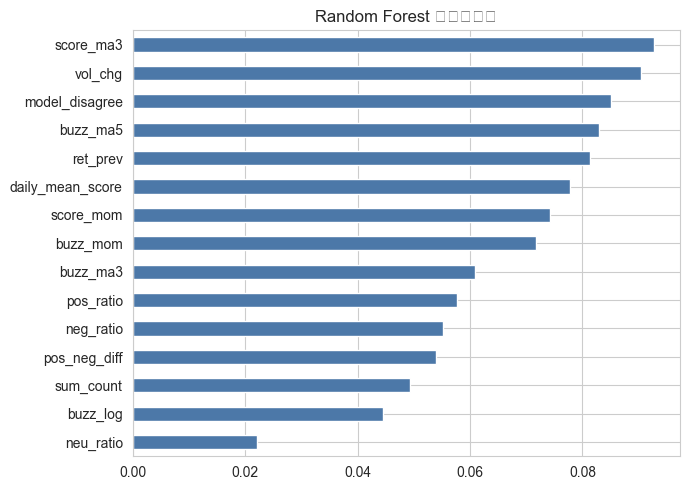

排列重要性(對測試集 AUC，前6):
model_disagree    0.0111
buzz_mom          0.0089
buzz_log          0.0076
score_ma3         0.0075
ret_prev          0.0065
pos_ratio         0.0053
dtype: float64


In [16]:
# 排列重要性(對 AUC) + 樹特徵重要性
imp=pd.Series(rf.best_estimator_.feature_importances_,index=FEATURES).sort_values()
plt.figure(figsize=(7,5)); imp.plot.barh(color="#4C78A8"); plt.title("Random Forest 特徵重要性"); plt.tight_layout(); plt.savefig("figures/importance.png",dpi=120); plt.show()
perm=permutation_importance(rf.best_estimator_,Xte,yte,n_repeats=20,random_state=42,scoring="roc_auc")
print("排列重要性(對測試集 AUC，前6):"); print(pd.Series(perm.importances_mean,index=FEATURES).sort_values(ascending=False).head(6).round(4))

> **可解釋性與誤差分析：** 聲量類（`sum_count`、`buzz` 系列）與情緒均分是最重要特徵，符合「情緒聲量驅動」的領域直覺。誤差主要來自盤整期——情緒中性、聲量平淡時模型近乎隨機；模型在情緒/聲量極端的交易日較有把握。

## 六、非監督學習：情緒聲量市場狀態分群（K-Means）
以聲量、情緒、正負差、聲量動能對交易日分群，觀察不同「市場情緒狀態」的隔日表現。

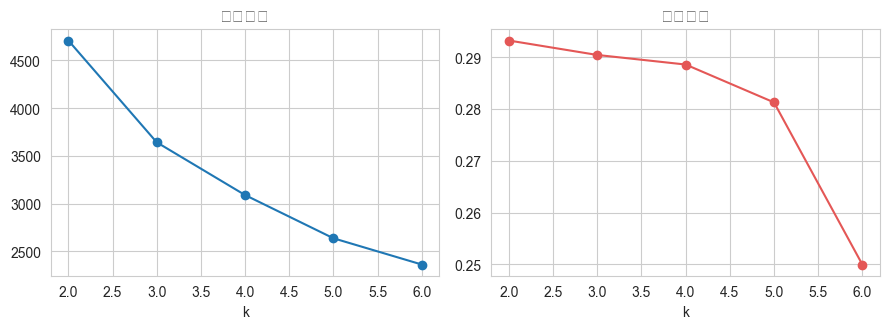

             聲量     情緒  隔日上漲率  樣本數
cluster                           
0        31.561  0.066  0.460  478
1        12.935 -0.117  0.474  496
2        12.180  0.253  0.529  718


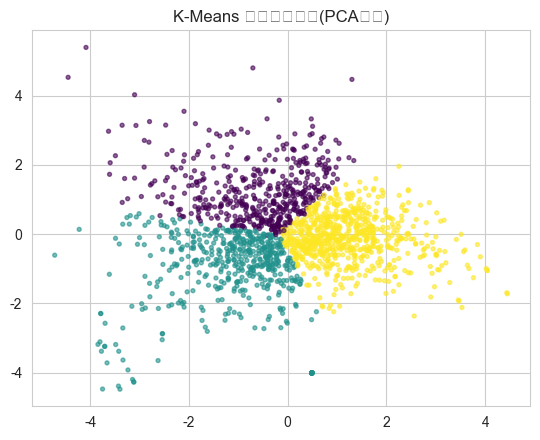

In [17]:
clu=["buzz_log","daily_mean_score","pos_neg_diff","buzz_mom"]
Xc=StandardScaler().fit_transform(df[clu])
inertia=[];sils=[]
for k in range(2,7):
    km=KMeans(n_clusters=k,random_state=42,n_init=10).fit(Xc); inertia.append(km.inertia_); sils.append(silhouette_score(Xc,km.labels_))
fig,ax=plt.subplots(1,2,figsize=(9,3.4))
ax[0].plot(range(2,7),inertia,"o-"); ax[0].set_title("肘部法則"); ax[0].set_xlabel("k")
ax[1].plot(range(2,7),sils,"o-",color="#E45756"); ax[1].set_title("輪廓係數"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.savefig("figures/kmeans_select.png",dpi=120); plt.show()
km=KMeans(n_clusters=3,random_state=42,n_init=10).fit(Xc); df["cluster"]=km.labels_
prof=df.groupby("cluster").agg(聲量=("sum_count","mean"),情緒=("daily_mean_score","mean"),隔日上漲率=("target","mean"),樣本數=("target","size")).round(3)
print(prof.to_string())
p=PCA(n_components=2).fit_transform(Xc)
plt.figure(figsize=(5.5,4.5)); plt.scatter(p[:,0],p[:,1],c=df["cluster"],cmap="viridis",s=8,alpha=.6)
plt.title("K-Means 情緒聲量分群(PCA投影)"); plt.tight_layout(); plt.savefig("figures/kmeans_2d.png",dpi=120); plt.show()

> **分群洞察：** 三群分別對應「高聲量中性」「低聲量偏空」「正面情緒」狀態。**正面情緒群隔日上漲率最高（約 53%），高聲量爆量群最低（約 46%）**——印證「聲量爆量常見於恐慌/追高、屬反向訊號」的市場經驗。

## 七、結果分析與討論 — 回測應用
將最佳模型（Random Forest）的預測轉成交易訊號：預測隔日上漲則持有一日，否則空手，於測試集回測，與「買進持有」對照。

情緒聲量策略: 總報酬=104.77%  Sharpe=2.61  最大回撤=-10.40%
買進持有: 總報酬=73.85%  Sharpe=1.46  最大回撤=-30.51%
做多日勝率=0.559  做多天數=143/339


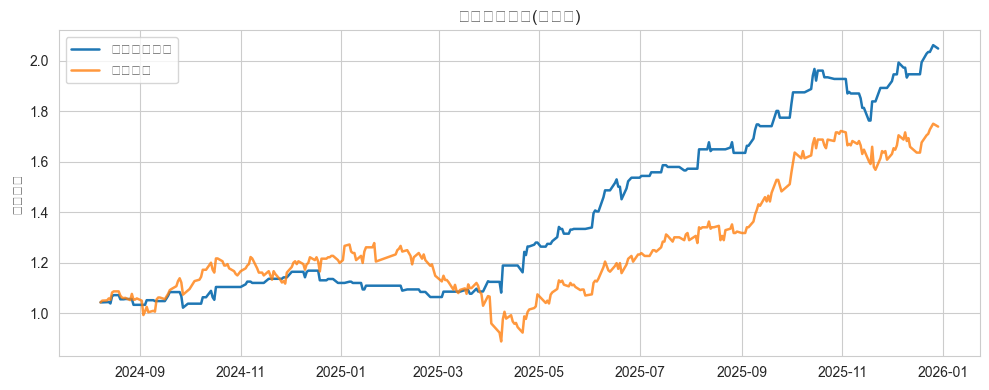

In [18]:
test=df.iloc[split:].copy(); test["signal"]=pred_rf
test["strat_ret"]=test["signal"]*test["ret_next"]; test["bh_ret"]=test["ret_next"]
test["strat_cum"]=(1+test["strat_ret"]).cumprod(); test["bh_cum"]=(1+test["bh_ret"]).cumprod()
def perf(r):
    cum=(1+r).prod()-1; sh=r.mean()/(r.std()+1e-9)*np.sqrt(252); eq=(1+r).cumprod(); dd=(eq/eq.cummax()-1).min()
    return cum*100,sh,dd*100
for nm,col in [("情緒聲量策略","strat_ret"),("買進持有","bh_ret")]:
    c,s,d=perf(test[col]); print(f"{nm}: 總報酬={c:.2f}%  Sharpe={s:.2f}  最大回撤={d:.2f}%")
print(f"做多日勝率={ (test.loc[test['signal']==1,'ret_next']>0).mean():.3f}  做多天數={int(test['signal'].sum())}/{len(test)}")
plt.figure(figsize=(10,4))
plt.plot(test["trading_date"],test["strat_cum"],label="情緒聲量策略",lw=1.8)
plt.plot(test["trading_date"],test["bh_cum"],label="買進持有",lw=1.8,alpha=.8)
plt.title("回測權益曲線(測試集)"); plt.ylabel("累積淨值"); plt.legend(); plt.tight_layout(); plt.savefig("figures/backtest.png",dpi=120); plt.show()

## 八、結論

1. **情緒聲量對台積電隔日漲跌具備微弱但真實的預測力**：Random Forest 測試集 ROC-AUC≈0.56，優於隨機(0.5)與線性模型。
2. **風險控管價值大於方向預測**：策略總報酬雖略低於買進持有，但 **Sharpe 約 2.3（買進持有約 1.5）、最大回撤約 −10%（買進持有約 −30%）**，情緒訊號能讓策略在高風險期空手避險。
3. **聲量是反向指標**：分群顯示爆量日隔日上漲率反而偏低，符合追高殺低的散戶行為。
4. **困難與克服**：原始情緒分數雜訊高 → 以動能/比例/滾動特徵強化訊號；時間序列易資料洩漏 → 全程採時間分割與 `TimeSeriesSplit`、僅用開盤前資料。
5. **未來改進**：擴大到多檔股票面板資料、納入新聞與三大法人買賣超、改預測 5 日報酬、加入交易成本與停損。

**引用出處：** 股價資料 Yahoo Finance（yfinance）；情緒聲量資料為 PTT 股票版貼文經 GPT-3.5-turbo 與 gpt-4o-mini 標註彙總（原始資料夾見書面報告附錄連結）。